PROYECTO DIPLOMATURA EN CIENCIA DE DATOS Y ANÁLISIS AVANZADO

# Sección nueva

In [ ]:
# Importamos todas las librerías necesarias para nuestro proyecto
# Manipulación de datos
import pandas as pd
import numpy as np

# Visualización
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocesamiento
from sklearn.preprocessing import StandardScaler

# Clustering
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Modelos predictivos
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

# Métricas
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, roc_curve, silhouette_score

# Configuración visual
sns.set(style="whitegrid")

In [ ]:
#cargamos los datos
df = pd.read_csv("Online Retail.csv", encoding='utf-8-sig')

EDA

In [ ]:
# convertimos la columna 'InvoiceDate' a formato datetime y extraemos solo la fecha
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'], format='%m/%d/%y %H:%M')
df['InvoiceDate'] = df['InvoiceDate'].dt.date

In [ ]:
# analizamos la cabecera del dataframe para entender su estructura
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01,3.39,17850.0,United Kingdom


In [ ]:
# obtenemos información general del dataframe para identificar tipos de datos, valores nulos y estadísticas básicas
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


In [ ]:
# obtenemos estadísticas descriptivas para las columnas numéricas del dataframe
df.describe()

,Quantity,UnitPrice,CustomerID
count,541909.000000,541909.000000,406829.000000
mean,9.552250,4.611114,15287.690570
std,218.081158,96.759853,1713.600303
min,-80995.000000,-11062.060000,12346.000000
25%,1.000000,1.250000,13953.000000
50%,3.000000,2.080000,15152.000000
75%,10.000000,4.130000,16791.000000
max,80995.000000,38970.000000,18287.000000


In [ ]:
#identificación de valores nulos en el dataframe para evaluar la calidad de los datos y planificar estrategias de limpieza o imputación
df.isnull().sum()

,0
InvoiceNo,0
StockCode,0
Description,1454
Quantity,0
InvoiceDate,0
UnitPrice,0
CustomerID,135080
Country,0


In [ ]:
#identificación de valores nulos en la columna 'CustomerID' para evaluar su impacto en el análisis y decidir si es necesario imputar o eliminar estas filas

null_customerid_count = df['CustomerID'].isnull().sum()
total_rows = len(df)

share_null_customerid = (null_customerid_count / total_rows) * 100

print(f"Number of null CustomerIDs: {null_customerid_count}")
print(f"Total rows: {total_rows}")
print(f"Share of null CustomerIDs: {share_null_customerid:.2f}%")

Number of null CustomerIDs: 135080
Total rows: 541909
Share of null CustomerIDs: 24.93%


In [ ]:
# Contamos las facturas que comienzan con 'C' para identificar transacciones canceladas y evaluar su proporción en el conjunto de datos
invoices_starting_with_c = df[df['InvoiceNo'].astype(str).str.startswith('C')]
count_invoices_c = len(invoices_starting_with_c)

print(f"Número de facturas que comienzan con 'C': {count_invoices_c}")

share_cancelled_invoices = (count_invoices_c / total_rows) * 100

print(f"Share of cancelled invoices: {share_cancelled_invoices:.2f}%")

Número de facturas que comienzan con 'C': 9288
Share of cancelled invoices: 1.71%


In [ ]:
# Contamos las transacciones con cantidades negativas
negative_quantity_count = len(df[df['Quantity'] < 0])

# Calculamos el porcentaje
share_negative_quantities = (negative_quantity_count / total_rows) * 100

print(f"Número de transacciones con cantidades negativas: {negative_quantity_count}")
print(f"Share de transacciones con cantidades negativas: {share_negative_quantities:.2f}%")

Número de transacciones con cantidades negativas: 10624
Share de transacciones con cantidades negativas: 1.96%


In [ ]:
# Contamos las transacciones con precios negativos para ver su importancia en el análisis y decidir si es necesario limpiarlas o tratarlas de alguna manera

negative_unitprice_count = len(df[df['UnitPrice'] < 0])
total_rows = len(df)

share_negative_unitprice = (negative_unitprice_count / total_rows) * 100

print(f"Número de transacciones con precios negativos: {negative_unitprice_count}")
print(f"Total de filas: {total_rows}")
print(f"Proporción de transacciones con precios negativos: {share_negative_unitprice:.2f}%")

Número de transacciones con precios negativos: 2
Total de filas: 541909
Proporción de transacciones con precios negativos: 0.00%


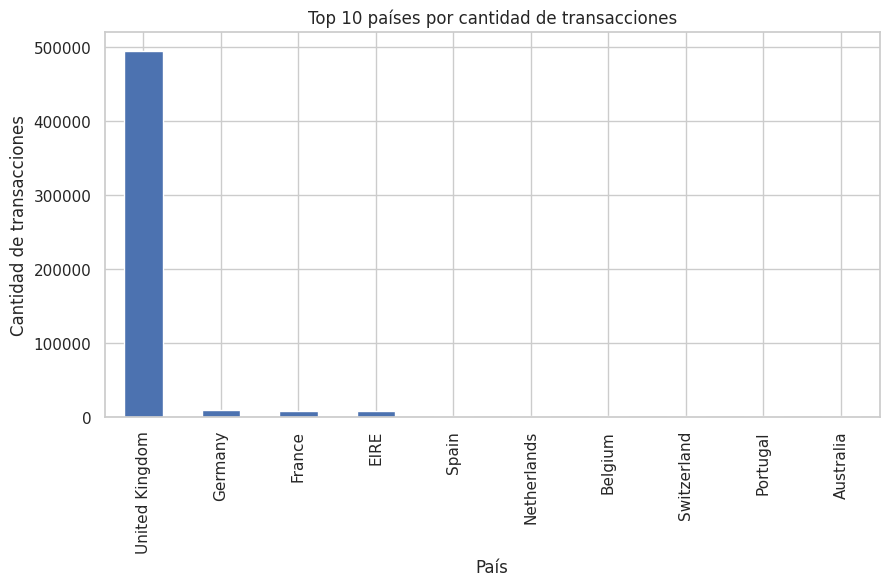

In [ ]:
# Visualizamos los 10 países con más transacciones para entender la distribución geográfica de las ventas y enfocar análisis posteriores en los mercados más relevantes
plt.figure(figsize=(10,5))
df['Country'].value_counts().head(10).plot(kind='bar')
plt.title("Top 10 países por cantidad de transacciones")
plt.xlabel("País")
plt.ylabel("Cantidad de transacciones")
plt.show()

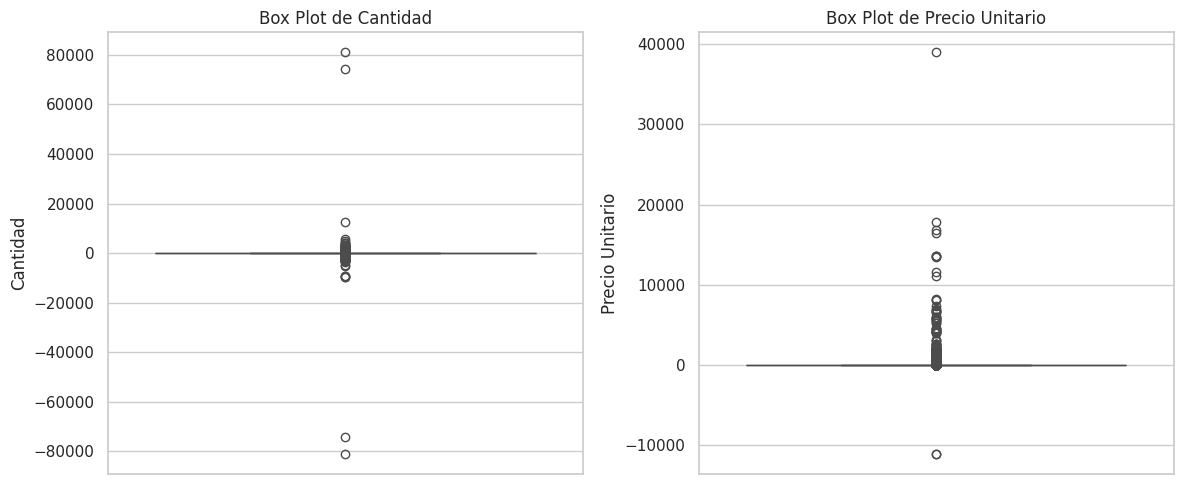

In [ ]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.boxplot(y=df['Quantity'])
plt.title('Box Plot de Cantidad')
plt.ylabel('Cantidad')

plt.subplot(1, 2, 2)
sns.boxplot(y=df['UnitPrice'])
plt.title('Box Plot de Precio Unitario')
plt.ylabel('Precio Unitario')

plt.tight_layout()
plt.show()

In [ ]:
producto_mas_caro = df.loc[df['UnitPrice'].idxmax()]
description_producto_mas_caro = producto_mas_caro['Description']

print(f"La descripción del producto con el precio unitario más alto es: '{description_producto_mas_caro}'")
print(f"Con un precio unitario de: {producto_mas_caro['UnitPrice']}")

La descripción del producto con el precio unitario más alto es: 'Manual'
Con un precio unitario de: 38970.0


In [ ]:
# Identificamos el índice de la fila con el precio unitario más alto
idx_producto_mas_caro = df['UnitPrice'].idxmax()

# Eliminamos esa fila del DataFrame
df = df.drop(idx_producto_mas_caro)

print(f"Se ha eliminado la fila con el producto de precio unitario más alto (índice: {idx_producto_mas_caro}).")
print("Ahora el dataframe no contiene ese caso extremo.")

Se ha eliminado la fila con el producto de precio unitario más alto (índice: 222681).
Ahora el dataframe no contiene ese caso extremo.


In [ ]:
# Opcional: Verificamos que se haya eliminado mostrando el nuevo producto más caro (si lo hay) o las estadísticas descriptivas
df.describe()

,Quantity,UnitPrice,CustomerID
count,541908.000000,541908.000000,406828.000000
mean,9.552269,4.539210,15287.691037
std,218.081359,80.998186,1713.602384
min,-80995.000000,-11062.060000,12346.000000
25%,1.000000,1.250000,13953.000000
50%,3.000000,2.080000,15152.000000
75%,10.000000,4.130000,16791.000000
max,80995.000000,17836.460000,18287.000000


LIMPIEZA

In [ ]:
#eliminamos filas sin cliente
df = df.dropna(subset=['CustomerID'])

In [ ]:
#eliminamos facturas canceladas
df = df[~df['InvoiceNo'].astype(str).str.startswith('C')]

In [ ]:
#eliminamos devoluciones
df = df[df['Quantity'] > 0]

In [ ]:
#eliminamos precios negativos
df = df[df['UnitPrice'] > 0]

CREACIÓN DE VARIABLES

In [ ]:
#Creamos la variable de gasto
df['TotalPrice'] = df['Quantity'] * df['UnitPrice']

In [ ]:
# Definimos una fecha de referencia (un día después de la última compra) para el analisis de RFM (Recency, Frequency, Monetary) para segmentar clientes.
snapshot_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)

In [ ]:
# identifico las variables que quedaron después de la limpieza para asegurarme de que tengo las columnas necesarias para el análisis
df.columns

Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country', 'TotalPrice'],
      dtype='object')

In [ ]:
# Agrupamos por cliente único para calcular las métricas RFM y lo incluimos en un nuevo dataframe llamado 'rfm' para facilitar el análisis de segmentación de clientes basado en estas métricas clave
rfm = df.groupby('CustomerID').agg({

    # Recency: días desde la última compra hasta la fecha de referencia
    'InvoiceDate': lambda x: (snapshot_date - x.max()).days,

    # Frequency: número de compras realizadas
    'InvoiceNo': 'nunique',

    # Monetary: dinero total gastado
    'TotalPrice': 'sum'

})

In [ ]:
# Cambiamos nombres de columnas para mayor claridad
rfm.columns = ['Recency', 'Frequency', 'Monetary']

In [ ]:
# Mostramos las primeras filas del dataset RFM
rfm.head()

,Recency,Frequency,Monetary
CustomerID,,,
12346.0,326,1,77183.60
12347.0,3,7,4310.00
12348.0,76,4,1797.24
12349.0,19,1,1757.55
12350.0,311,1,334.40


In [ ]:
# Creamos el objeto que va a escalar los datos
scaler = StandardScaler()

# Aplicamos el escalado a las variables RFM y lo guardamos en un nuevo dataframe llamado 'rfm_scaled' para tener las métricas RFM normalizadas y listas para el análisis de clustering, lo que permitirá que el modelo no se vea sesgado por la escala de las variables. Esto es importante para no usar luego variables escaladas en los modelos predictivos.
rfm_scaled = scaler.fit_transform(rfm)

# Convertimos el resultado nuevamente en DataFrame para poder trabajar cómodo
rfm_scaled = pd.DataFrame(rfm_scaled, columns=rfm.columns)

# Miramos las primeras filas para verificar
rfm_scaled.head()

,Recency,Frequency,Monetary
0,2.329388,-0.425097,8.358668
1,-0.900588,0.354417,0.250966
2,-0.170593,-0.035340,-0.028596
3,-0.740589,-0.425097,-0.033012
4,2.179389,-0.425097,-0.191347


In [ ]:
# Lista donde guardaremos la inercia de cada modelo (suma de las distancias al cuadrado de cada punto a su centroide más cercano, que es una medida de la calidad del clustering)
inertia = []

# Probamos distintos números de clusters (de 1 a 10)
K = range(1,11)

for k in K:

    # Creamos el modelo KMeans con k clusters y asignamos random_state para reproducibilidad
    kmeans = KMeans(n_clusters=k, random_state=42)

    # Entrenamos el modelo con los datos escalados
    kmeans.fit(rfm_scaled)

    # Guardamos la inercia (medida de error del modelo)
    inertia.append(kmeans.inertia_)

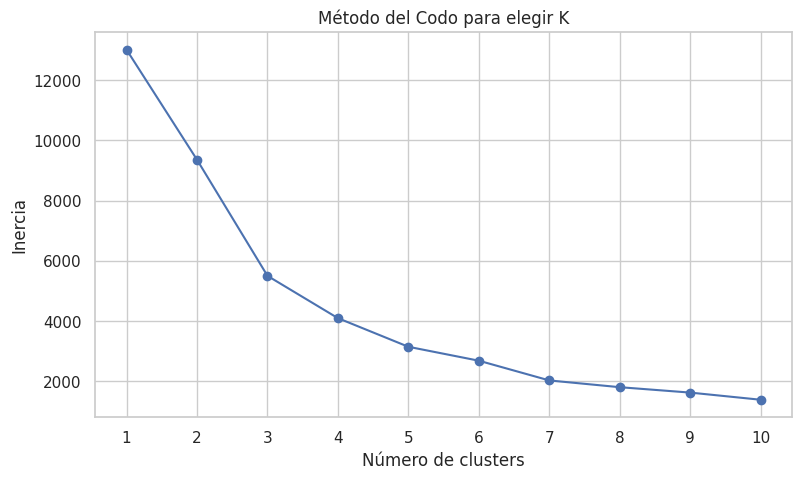

In [ ]:
# Graficamos el método del codo realizado previamente para elegir el número óptimo de clusters (K) para el modelo KMeans, donde se observa la inercia en función de K y se busca el punto donde la disminución de la inercia se vuelve menos pronunciada (el "codo"), lo que indica un buen equilibrio entre la calidad del clustering y la simplicidad del modelo.

plt.figure(figsize=(9,5))

# Dibujamos la curva de inercia
plt.plot(K, inertia, marker='o')

# Títulos del gráfico
plt.title("Método del Codo para elegir K")
plt.xlabel("Número de clusters")
plt.ylabel("Inercia")
plt.xticks(K)

plt.show()

In [ ]:
# Creamos el modelo KMeans con 4 clusters
kmeans = KMeans(n_clusters=4, random_state=42)

# Entrenamos el modelo y asignamos cada cliente a un cluster
rfm['Cluster'] = kmeans.fit_predict(rfm_scaled)

# Miramos el resultado
rfm.head()

,Recency,Frequency,Monetary,Cluster
CustomerID,,,,
12346.0,326,1,77183.60,3
12347.0,3,7,4310.00,0
12348.0,76,4,1797.24,0
12349.0,19,1,1757.55,0
12350.0,311,1,334.40,1


In [ ]:
# prueba de sensibilidad a outliers (va eliminando gradualmente a los clientes de mayor gasto)
def prueba_sensibilidad_outliers(dataframe_rfm, percentil):
    limite = dataframe_rfm['Monetary'].quantile(percentil)
    df_filtrado = dataframe_rfm[dataframe_rfm['Monetary'] <= limite].copy()

    scaler_temp = StandardScaler()
    datos_escalados = scaler_temp.fit_transform(df_filtrado[['Recency', 'Frequency', 'Monetary']])

    kmeans_temp = KMeans(n_clusters=4, random_state=42, n_init=10)
    df_filtrado['Cluster_Temp'] = kmeans_temp.fit_predict(datos_escalados)

    print(f"--- Resultados reteniendo el {percentil*100}% de los datos ---")
    print(f"Límite de corte monetario: £{limite:.2f}")
    print(f"Clientes retenidos: {len(df_filtrado)}")
    display(df_filtrado.groupby('Cluster_Temp')[['Recency', 'Frequency', 'Monetary']].mean().round(2))
    print("\n")

# Probamos 3 escenarios distintos
umbrales = [0.99, 0.95, 0.90]
for u in umbrales:
    prueba_sensibilidad_outliers(rfm, u)

--- Resultados reteniendo el 99.0% de los datos ---
Límite de corte monetario: £19881.00
Clientes retenidos: 4294


,Recency,Frequency,Monetary
Cluster_Temp,,,
0,50.35,2.53,780.52
1,27.77,8.54,3391.07
2,252.28,1.49,434.52
3,14.64,21.70,9847.37




--- Resultados reteniendo el 95.0% de los datos ---
Límite de corte monetario: £5841.84
Clientes retenidos: 4121


,Recency,Frequency,Monetary
Cluster_Temp,,,
0,53.82,2.07,570.73
1,21.46,12.55,4030.90
2,255.30,1.44,405.15
3,37.69,5.58,2129.09




--- Resultados reteniendo el 90.0% de los datos ---
Límite de corte monetario: £3646.53
Clientes retenidos: 3904


,Recency,Frequency,Monetary
Cluster_Temp,,,
0,258.15,1.39,384.28
1,45.83,4.27,1538.31
2,55.95,1.83,461.56
3,27.95,8.72,2608.02


In [ ]:
# Calculamos el promedio de Recency, Frequency y Monetary por cluster
cluster_summary = rfm.groupby('Cluster').mean()

cluster_summary

,Recency,Frequency,Monetary
Cluster,,,
0,44.433007,3.678758,1358.166913
1,249.173421,1.551367,478.194732
2,7.615385,82.538462,127338.313846
3,15.955882,22.333333,12709.090490


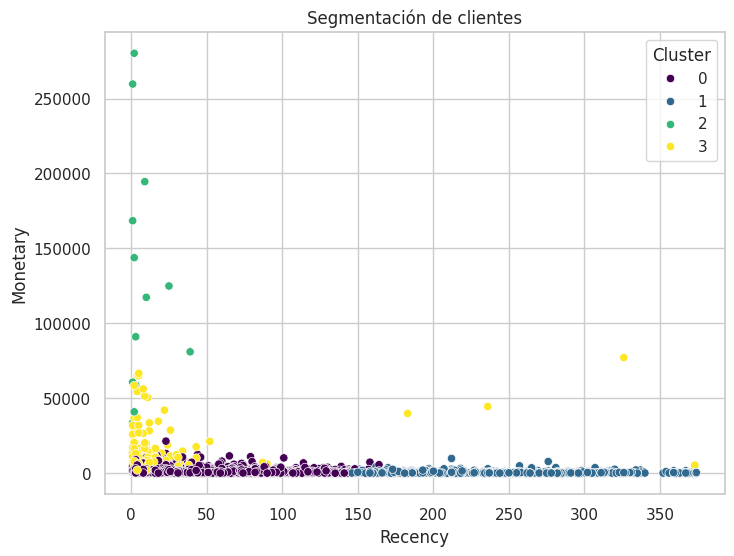

In [ ]:
# Creamos el gráfico
plt.figure(figsize=(8,6))

sns.scatterplot(
    x='Recency',      # eje X
    y='Monetary',     # eje Y
    hue='Cluster',    # color según cluster
    data=rfm,
    palette='viridis'
)

# Título del gráfico
plt.title("Segmentación de clientes")

plt.show()

In [ ]:
# Creamos una variable que indique clientes de alto valor
# Ahora consideramos alto valor a los clusters 2 y 3

rfm['HighValue'] = rfm['Cluster'].apply(lambda x: 1 if x in [2,3] else 0)

# Verificamos cuántos clientes hay en cada categoría
rfm['HighValue'].value_counts()

,count
HighValue,
0,4121
1,217


In [ ]:
rfm['Cluster'].value_counts()

,count
Cluster,
0,3060
1,1061
3,204
2,13


In [ ]:
# Calculamos el score usando los datos escalados y las etiquetas que puso el K-Means
score_s = silhouette_score(rfm_scaled, rfm['Cluster'])
print(f"Silhouette Score: {score_s:.3f}")

if score_s > 0.4:
    print("Umbral de éxito CUMPLIDO (> 0.4)")

Silhouette Score: 0.616
Umbral de éxito CUMPLIDO (> 0.4)


In [ ]:
# ==============================================================================
# ESTRATEGIA: VENTANA TEMPORAL (9 meses Observación / 3 meses Predicción)
# ==============================================================================
# 1. CORRECCIÓN DE TIPO: Aseguramos que InvoiceDate sea Timestamp para comparar.
# 2. DIVISIÓN: Punto de corte a los 9 meses desde el inicio del dataset.
# 3. X (PASADO): Comportamiento RFM calculado sobre los primeros 9 meses.
# 4. y (FUTURO): Identifica clientes de "Alto Valor" en los últimos 3 meses.
# ==============================================================================

# 0. Corrección de formato para evitar el TypeError
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

# 1. Definir fecha de corte (9 meses desde la primera factura)
fecha_inicio = df['InvoiceDate'].min()
fecha_corte = fecha_inicio + pd.DateOffset(months=9)

# 2. Separar periodos: Pasado (Entrenamiento) y Futuro (Objetivo)
df_pasado = df[df['InvoiceDate'] < fecha_corte].copy()
df_futuro = df[df['InvoiceDate'] >= fecha_corte].copy()

# 3. Generar Variables X (Basadas en el comportamiento pasado)
snapshot = df_pasado['InvoiceDate'].max() + pd.DateOffset(days=1)

X_predictivo = df_pasado.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (snapshot - x.max()).days,
    'InvoiceNo': 'nunique',
    'TotalPrice': 'sum'
}).rename(columns={
    'InvoiceDate': 'Recency',
    'InvoiceNo': 'Frequency',
    'TotalPrice': 'Monetary'
})

# 4. Generar Variable y (Basada en el resultado futuro)
# Calculamos cuánto gastó cada cliente en el periodo final de 3 meses
gasto_futuro = df_futuro.groupby('CustomerID')['TotalPrice'].sum().reset_index()

# Definimos "Alto Valor" como el Top 25% de los que compraron en ese periodo
umbral_futuro = gasto_futuro['TotalPrice'].quantile(0.75)
gasto_futuro['HighValue_Future'] = (gasto_futuro['TotalPrice'] > umbral_futuro).astype(int)

# 5. Consolidación Final
# Unimos X con y. Quienes no compraron en el futuro reciben 0 automáticamente.
final_df = X_predictivo.merge(
    gasto_futuro[['CustomerID', 'HighValue_Future']],
    on='CustomerID',
    how='left'
).fillna(0)

# Definición de variables finales para los modelos
X = final_df[['Recency', 'Frequency', 'Monetary']]
y = final_df['HighValue_Future']

print(f"Dataset listo para ML.")
print(f"Registros totales: {len(final_df)}")
print(f"Clientes que resultaron de Alto Valor en el futuro: {y.sum()}")

Dataset listo para ML.
Registros totales: 3317
Clientes que resultaron de Alto Valor en el futuro: 599.0


In [ ]:
#ANALISIS DE LOS TRES MODELOS PREDICTIVOS

# 1. Dividimos los datos (80% para entrenar, 20% para probar)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)

# 2. Escalamos los datos
scaler_pred = StandardScaler()
X_train_scaled = scaler_pred.fit_transform(X_train)
X_test_scaled = scaler_pred.transform(X_test)

# 3. Entrenamos los 3 modelos propuestos
lr = LogisticRegression(random_state=42)
rf_model = RandomForestClassifier(random_state=42)
svm = SVC(probability=True, random_state=42)

lr.fit(X_train_scaled, y_train)
rf_model.fit(X_train_scaled, y_train)
svm.fit(X_train_scaled, y_train)

# 4. Evaluamos los modelos y creamos la tabla
def evaluar_modelo(nombre, modelo, X_test, y_test):
    y_pred = modelo.predict(X_test)
    y_proba = modelo.predict_proba(X_test)[:, 1]
    return {
        'Modelo': nombre,
        'Accuracy': round(accuracy_score(y_test, y_pred), 3),
        'Precision': round(precision_score(y_test, y_pred), 3),
        'Recall': round(recall_score(y_test, y_pred), 3),
        'F1-Score': round(f1_score(y_test, y_pred), 3),
        'ROC-AUC': round(roc_auc_score(y_test, y_proba), 3)
    }

resultados = [
    evaluar_modelo('Regresión Logística', lr, X_test_scaled, y_test),
    evaluar_modelo('Random Forest', rf_model, X_test_scaled, y_test),
    evaluar_modelo('SVM', svm, X_test_scaled, y_test)
]

print("=== COMPARATIVA DE MODELOS PREDICTIVOS ===")
display(pd.DataFrame(resultados))

=== COMPARATIVA DE MODELOS PREDICTIVOS ===


,Modelo,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Regresión Logística,0.870,0.804,0.375,0.511,0.829
1,Random Forest,0.870,0.677,0.542,0.602,0.830
2,SVM,0.878,0.868,0.383,0.532,0.799


In [ ]:
# OPTIMIZACIÓN DEL MODELO RANDOM FOREST PARA BUSCAR LA MEJOR COMBINACIÓN DE HIPERPARÁMETROS

# 1. Definimos la malla de hiperparámetros para Random Forest
# n_estimators: cantidad de árboles
# max_depth: profundidad para evitar overfitting
# class_weight: 'balanced' ayuda mucho cuando hay pocos clientes de "Alto Valor"
param_grid_rf = {
    'n_estimators': [100, 200],
    'max_depth': [5, 10, None],
    'min_samples_split': [2, 5],
    'class_weight': ['balanced', None]
}

# 2. Configuramos la búsqueda (optimizamos por F1 para balancear Precision y Recall)
grid_rf = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid_rf,
    cv=5,
    scoring='f1',
    verbose=1,
    n_jobs=-1 # Usa todos los núcleos del procesador para ir más rápido
)

# 3. Entrenamos (usando tus variables X e y del split temporal)
# Recuerda: Random Forest no requiere escalado obligatoriamente, pero puedes usar X_train_scaled si prefieres
grid_rf.fit(X_train, y_train)

print(f"Mejores parámetros: {grid_rf.best_params_}")

# 4. Evaluamos el modelo optimizado
best_rf = grid_rf.best_estimator_
resultado_rf_opt = evaluar_modelo('Random Forest Optimizado', best_rf, X_test, y_test)

display(pd.DataFrame([resultado_rf_opt]))

# JUSTIFICACIÓN: Uso de class_weight='balanced'
# ------------------------------------------------------------------------------
# Debido a que los clientes de "Alto Valor" son una minoría en el dataset, el modelo tiende a ignorarlos para maximizar el Accuracy global.
# Al usar 'balanced', penalizamos más los errores en la clase minoritaria.
# RESULTADO: Aumenta el RECALL (identificamos más futuros VIPs), aunque asumimos más "falsos positivos" (menor precisión).
# Estrategia: Captura agresiva de oportunidades de negocio.

Fitting 5 folds for each of 24 candidates, totalling 120 fits
Mejores parámetros: {'class_weight': 'balanced', 'max_depth': 5, 'min_samples_split': 5, 'n_estimators': 100}


,Modelo,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Random Forest Optimizado,0.813,0.488,0.683,0.569,0.855


Fitting 5 folds for each of 36 candidates, totalling 180 fits
Mejores parámetros: {'class_weight': None, 'max_depth': 7, 'min_samples_leaf': 6, 'n_estimators': 200}


,Modelo,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Random Forest Final,0.884,0.759,0.525,0.621,0.859


/tmp/ipykernel_996/253286586.py:42: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importancia', y='Variable', data=importancias, palette='viridis')


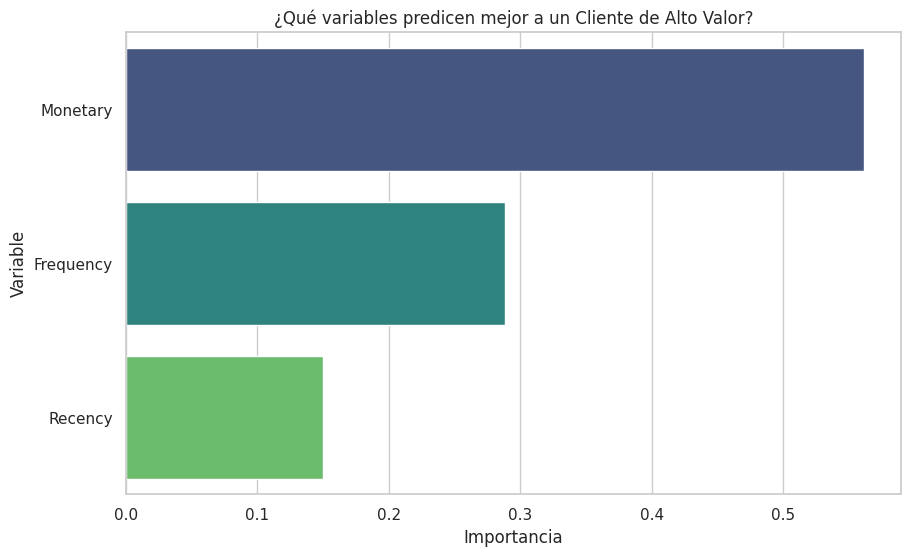

In [ ]:
# 1. Definimos una malla que busca estabilidad y balance
param_grid_final = {
    'n_estimators': [100, 200],
    'max_depth': [7, 10, 12],            # Profundidad moderada para no sobreajustar
    'min_samples_leaf': [2, 4, 6],       # Hojas más grandes para ganar estabilidad
    'class_weight': [None, 'balanced']   # Dejamos que el Grid elija si necesita balanceo o no
}

# 2. Cambiamos el scoring a 'roc_auc'
# Esto busca maximizar la probabilidad de que un VIP tenga mayor score que un NO-VIP
grid_final = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid_final,
    cv=5,
    scoring='roc_auc',
    verbose=1,
    n_jobs=-1
)

grid_final.fit(X_train, y_train)

# 3. Resultados del modelo final
best_rf_final = grid_final.best_estimator_
res_final = evaluar_modelo('Random Forest Final', best_rf_final, X_test, y_test)

print(f"Mejores parámetros: {grid_final.best_params_}")
display(pd.DataFrame([res_final]))

# ==============================================================================
# GRÁFICO DE IMPORTANCIA DE VARIABLES
# ==============================================================================
importancias = pd.DataFrame({
    'Variable': X.columns,
    'Importancia': best_rf_final.feature_importances_
}).sort_values(by='Importancia', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importancia', y='Variable', data=importancias, palette='viridis')
plt.title('¿Qué variables predicen mejor a un Cliente de Alto Valor?')
plt.show()

# JUSTIFICACIÓN: Uso de class_weight=None (Por defecto)
# ------------------------------------------------------------------------------
# Se opta por no balancear artificialmente las clases para priorizar la PRECISIÓN del modelo.
# Se busca que cada predicción de "Alto Valor" sea altamente confiable, evitando el gasto innecesario de recursos de marketing
# en clientes que no retornarán la inversión.
# RESULTADO: Mayor estabilidad y precisión, sacrificando la detección de algunos clientes valiosos (menor recall).
# Estrategia: Eficiencia operativa y optimización del ROI.

In [ ]:
#EVALUACION DE ESTABILIDAD TEMPORAL

print("=== EVALUACIÓN DE ESTABILIDAD TEMPORAL (Validación Cruzada - 5 Folds) ===\n")

# Evaluamos el Random Forest en 5 divisiones distintas de tus datos
scores_auc = cross_val_score(rf_model, X_train_scaled, y_train, cv=5, scoring='roc_auc')

for i, score in enumerate(scores_auc, 1):
    print(f"Prueba {i}: AUC = {score:.3f}")

promedio_auc = scores_auc.mean()
variacion_auc = scores_auc.std()

print(f"\nAUC Promedio: {promedio_auc:.3f}")
print(f"Variación (Desviación Estándar): +/- {variacion_auc:.3f}")

if variacion_auc < 0.05:
    print("\nVEREDICTO: El modelo es ALTAMENTE ESTABLE. No depende de una muestra específica de datos.")
else:
    print("\nVEREDICTO: El modelo presenta cierta inestabilidad temporal o sensibilidad a la muestra.")

=== EVALUACIÓN DE ESTABILIDAD TEMPORAL (Validación Cruzada - 5 Folds) ===

Prueba 1: AUC = 0.806
Prueba 2: AUC = 0.806
Prueba 3: AUC = 0.834
Prueba 4: AUC = 0.781
Prueba 5: AUC = 0.822

AUC Promedio: 0.810
Variación (Desviación Estándar): +/- 0.018

VEREDICTO: El modelo es ALTAMENTE ESTABLE. No depende de una muestra específica de datos.
